# LOST SIGNAL — Clean Final Notebook

**Multimodal disaster missing-person evidence intelligence**

Architecture: text evidence → **Gemma 4 E4B-IT** → structured clues; photo evidence → **PaliGemma 2 3B MIX 448** → grounded caption → **Gemma 4 E4B-IT** → structured clue.

The models are loaded sequentially and unloaded between phases to fit the Kaggle dual-T4 environment.


In [11]:
# CELL 0 — Kaggle environment setup
# Run first in a fresh Kaggle session. Keep Kaggle's existing Torch/CUDA dependencies unchanged.
!pip install -q transformers accelerate pillow networkx plotly pandas sentencepiece
!pip install -q --upgrade "git+https://github.com/huggingface/transformers.git"
 
print("Transformers source build installed for this session.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 16.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Transformers source build installed for this session.


In [12]:
# CELL 1 — Imports and environment setup
# =============================================================================

import os
import re
import json
import glob
import random
import textwrap
import gc
from datetime import datetime, timedelta

import pandas as pd
import numpy as np
import networkx as nx

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import plotly.graph_objects as go
import plotly.express as px

from PIL import Image

import torch
import transformers

from transformers import (
    AutoProcessor,
    AutoModelForImageTextToText,
    AutoModelForMultimodalLM
)

random.seed(42)
np.random.seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Transformers:", transformers.__version__)
print("Torch:", torch.__version__)
print("Device:", DEVICE)
print("GPU count:", torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

Transformers: 5.15.0.dev0
Torch: 2.10.0+cu128
Device: cuda
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4


In [13]:
# CELL 2 — Inspect mounted dataset structures BEFORE hardcoding paths
# -----------------------------------------------------------------------------
INPUT_ROOT = "/kaggle/input"
 
# Ground truth: list what Kaggle actually mounted, instead of guessing names
# from dataset URLs (owner renames, versioning, and slug differences mean the
# mount folder name doesn't always match the slug in the dataset's URL).
print("Actual mounted folders under /kaggle/input:")
for entry in sorted(os.listdir(INPUT_ROOT)):
    print(" -", entry)
 
def peek(dataset_slug, max_items=20):
    """Print a shallow tree of a mounted dataset so we can confirm real paths."""
    root = os.path.join(INPUT_ROOT, dataset_slug)
    if not os.path.isdir(root):
        print(f"[MISSING] {dataset_slug} not found at {root} — check it's attached in 'Add Data'.")
        return
    print(f"\n=== {dataset_slug} ===")
    count = 0
    for dirpath, dirnames, filenames in os.walk(root):
        depth = dirpath.replace(root, "").count(os.sep)
        indent = "  " * depth
        print(f"{indent}{os.path.basename(dirpath) or dirpath}/")
        for f in filenames[:5]:
            print(f"{indent}  {f}")
            count += 1
            if count >= max_items:
                return
        if depth > 2:  # don't recurse forever into deep image folders
            dirnames.clear()
 
DATASET_SLUGS = {
    "disaster_images": "varpit94/disaster-images-dataset",
    "c2a": "rgbnihal/c2a-dataset",
    "ncrb_missing": "arjoonn/missing-people",
    "synthetic_person": "swainproject/synthetic-data-person",
}
 
# IMPORTANT: the printed listing above (`os.listdir(INPUT_ROOT)`) is the
# SOURCE OF TRUTH for folder names — Kaggle's mount folder name is based on
# the dataset's display title / its own internal slug, which can differ from
# the "<owner>/<slug>" you see in a search-results URL. Do not assume any of
# the guesses below are right until you've checked them against the printed
# list.
#
# Peek every actually-mounted folder (not a guessed name) so we always see
# real structure:
for entry in sorted(os.listdir(INPUT_ROOT)):
    peek(entry)

Actual mounted folders under /kaggle/input:
 - datasets
 - models
 - notebooks

=== datasets ===
datasets/
  arjoonn/
    missing-people/
      cleandata.csv
  rgbnihal/
    c2a-dataset/
      C2A_Dataset/
      Coco_annotation_pose/
        train_annotations_with_pose_information.json
        test_annotations_with_pose_information.json
        val_annotations_with_pose_information.json
  varpit94/
    disaster-images-dataset/
      Comprehensive Disaster Dataset(CDD)/
  swainproject/
    synthetic-data-person/
      person_10000000.csv
      person_10000.csv
      person_1000000.csv
      person_5000000.csv
      person_100000.csv

=== models ===
models/
  google/
    paligemma-2/
      transformers/

=== notebooks ===
notebooks/
  haradibots/


In [14]:
# CELL 3 — Config: paths, sample sizes, output dirs
# -----------------------------------------------------------------------------
# Auto-discover mount paths instead of hardcoding folder names (the sidebar's
# "Disaster Images Dataset" display title, the URL slug, and the actual mount
# folder name under /kaggle/input/ can all differ — only the CELL 2 printout
# is trustworthy). Run CELL 2 first, then either:
#   (a) let this auto-match by keyword below, or
#   (b) if a match fails/picks the wrong one, hardcode the exact folder name
#       you saw printed in CELL 2 directly into the CONFIG dict further down.
 
mounted_folders = sorted(os.listdir(INPUT_ROOT))
print("Top-level mounted folders:", mounted_folders)
 
def find_mount(keyword_options):
    """Return the FULL PATH (relative to INPUT_ROOT) of the first directory,
    at ANY depth under INPUT_ROOT, whose name contains one of the given
    keywords. Needed because this Kaggle environment nests datasets under an
    extra datasets/<owner>/<slug>/ layer rather than mounting them directly
    at /kaggle/input/<slug>/."""
    for dirpath, dirnames, filenames in os.walk(INPUT_ROOT):
        base = os.path.basename(dirpath).lower()
        if any(kw in base for kw in keyword_options):
            return os.path.relpath(dirpath, INPUT_ROOT)
    return None
 
disaster_mount = find_mount(["disaster-image", "disaster_image", "comprehensive"])
c2a_mount = find_mount(["c2a"])
ncrb_mount = find_mount(["missing-people", "missing_people"])
synth_mount = find_mount(["synthetic-data-person", "synthetic_data_person", "person-record"])
 
print(f"disaster_mount = {disaster_mount}")
print(f"c2a_mount      = {c2a_mount}")
print(f"ncrb_mount     = {ncrb_mount}")
print(f"synth_mount    = {synth_mount}")
 
if not all([disaster_mount, c2a_mount, ncrb_mount, synth_mount]):
    print("\n[ACTION NEEDED] One or more datasets didn't auto-match. Look at "
          "'Top-level mounted folders' above (and CELL 2's full tree print) "
          "and hardcode the exact relative path directly, e.g.:\n"
          "    disaster_mount = 'datasets/varpit94/disaster-images-dataset'")
 
# Once *_mount values are correct, find the actual sub-path to images/CSVs
# within each (still auto-discovered, not guessed, using the CELL 2-style walk):
def find_dir_containing(rel_root, folder_name_contains, file_ext_hint=None):
    """Walk INPUT_ROOT/rel_root and return the first directory whose name
    matches, or that contains files with the given extension — used to locate
    e.g. Human_Damage or images/ subfolders without hardcoding deep nested
    paths. rel_root here is the relative path returned by find_mount (which
    may already include datasets/<owner>/<slug>/...)."""
    if not rel_root:
        return None
    root_path = os.path.join(INPUT_ROOT, rel_root)
    for dirpath, dirnames, filenames in os.walk(root_path):
        base = os.path.basename(dirpath).lower()
        if folder_name_contains and folder_name_contains.lower() in base:
            return dirpath
        if file_ext_hint and any(f.lower().endswith(file_ext_hint) for f in filenames):
            return dirpath
    return root_path  # fallback to dataset root if nothing more specific found
 
CONFIG = {
    "disaster_images_dir": (
        find_dir_containing(disaster_mount, "human_damage", (".png", ".jpg"))
        if disaster_mount else None
    ),
    "disaster_images_dir_2": (
        find_dir_containing(disaster_mount, "water_disaster", (".png", ".jpg"))
        if disaster_mount else None
    ),
    "c2a_dir": (
        find_dir_containing(c2a_mount, "images", (".png", ".jpg"))
        if c2a_mount else None
    ),
    "ncrb_csv_glob": f"{INPUT_ROOT}/{ncrb_mount}/*.csv" if ncrb_mount else None,
    "synthetic_person_csv_glob": (
        f"{INPUT_ROOT}/{synth_mount}/person_10000.csv" if synth_mount else None
    ),
 
    "n_photo_evidence": 10,      # how many images we pull in total for evidence cards
    "n_named_records": 8,        # how many real names/demographics we borrow
    "n_synthetic_padding": 15,   # bulk filler records to pad the graph to ~30 nodes
 
    "working_dir": "/kaggle/working",
    "evidence_dir": "/kaggle/working/evidence_images",
    "output_json": "/kaggle/working/evidence_store.json",
}
 
os.makedirs(CONFIG["evidence_dir"], exist_ok=True)
print(json.dumps(CONFIG, indent=2))

Top-level mounted folders: ['datasets', 'models', 'notebooks']
disaster_mount = datasets/varpit94/disaster-images-dataset
c2a_mount      = datasets/rgbnihal/c2a-dataset
ncrb_mount     = datasets/arjoonn/missing-people
synth_mount    = datasets/swainproject/synthetic-data-person
{
  "disaster_images_dir": "/kaggle/input/datasets/varpit94/disaster-images-dataset/Comprehensive Disaster Dataset(CDD)/Water_Disaster",
  "disaster_images_dir_2": "/kaggle/input/datasets/varpit94/disaster-images-dataset/Comprehensive Disaster Dataset(CDD)/Water_Disaster",
  "c2a_dir": "/kaggle/input/datasets/rgbnihal/c2a-dataset/C2A_Dataset/new_dataset3/val/images",
  "ncrb_csv_glob": "/kaggle/input/datasets/arjoonn/missing-people/*.csv",
  "synthetic_person_csv_glob": "/kaggle/input/datasets/swainproject/synthetic-data-person/person_10000.csv",
  "n_photo_evidence": 10,
  "n_named_records": 8,
  "n_synthetic_padding": 15,
  "working_dir": "/kaggle/working",
  "evidence_dir": "/kaggle/working/evidence_images",


In [15]:
# CELL 4 — Select a small photo subset (NOT the whole dataset) for evidence cards
# -----------------------------------------------------------------------------
import random
IMG_EXTS = (".jpg", ".jpeg", ".png")
 
def list_images(root_dir, limit=None):
    if not root_dir or not os.path.isdir(root_dir):
        return []
    paths = []
    for dirpath, _, filenames in os.walk(root_dir):
        for f in filenames:
            if f.lower().endswith(IMG_EXTS):
                paths.append(os.path.join(dirpath, f))
                if limit and len(paths) >= limit:
                    return paths
    return paths
 
def find_any_images(mount_folder, limit=50):
    """Fallback: walk the ENTIRE mounted dataset root looking for any image
    files at all, regardless of subfolder name. Used only if the targeted
    CONFIG path above turned up empty, so we can still get a working subset
    without needing the exact subfolder name to be right."""
    if not mount_folder:
        return []
    root_path = os.path.join(INPUT_ROOT, mount_folder)
    return list_images(root_path, limit=limit)
 
# --- Diagnostics: print exactly what paths CELL 3 resolved to, and whether
# they exist, BEFORE trying to use them. This is what tells us why a path
# returns 0 images. ---
print("disaster_images_dir   =", CONFIG.get("disaster_images_dir"),
      "| exists:", CONFIG.get("disaster_images_dir") and os.path.isdir(CONFIG["disaster_images_dir"]))
print("disaster_images_dir_2 =", CONFIG.get("disaster_images_dir_2"),
      "| exists:", CONFIG.get("disaster_images_dir_2") and os.path.isdir(CONFIG["disaster_images_dir_2"]))
print("c2a_dir                =", CONFIG.get("c2a_dir"),
      "| exists:", CONFIG.get("c2a_dir") and os.path.isdir(CONFIG["c2a_dir"]))
 
disaster_candidates = (
    list_images(CONFIG["disaster_images_dir"], limit=200)
    + list_images(CONFIG["disaster_images_dir_2"], limit=100)
)
c2a_candidates = list_images(CONFIG["c2a_dir"], limit=300)
 
# If the targeted subfolders came back empty, fall back to scanning the whole
# dataset mount for any images at all, rather than silently proceeding with 0.
if not disaster_candidates:
    print("[FALLBACK] Targeted disaster-images subfolder was empty — "
          "scanning the whole dataset mount instead.")
    disaster_candidates = find_any_images(disaster_mount, limit=200)
 
if not c2a_candidates:
    print("[FALLBACK] Targeted C2A images subfolder was empty — "
          "scanning the whole dataset mount instead.")
    c2a_candidates = find_any_images(c2a_mount, limit=200)
 
print(f"Found {len(disaster_candidates)} candidate disaster-scene images "
      f"(Human_Damage + Water_Disaster, or fallback scan)")
print(f"Found {len(c2a_candidates)} candidate C2A images (train/images, or fallback scan)")
 
if not disaster_candidates or not c2a_candidates:
    print("\n[ACTION NEEDED] Still 0 after fallback scan — this means the "
          "*_mount variable itself is wrong (dataset not actually mounted "
          "under that name), not just the subfolder. Go back to CELL 2's "
          "raw `os.listdir(INPUT_ROOT)` printout, copy the EXACT folder name "
          "you see for the missing dataset, and hardcode it directly, e.g.:\n"
          "    disaster_mount = 'exact-name-from-listdir'\n"
          "    c2a_mount = 'exact-name-from-listdir'\n"
          "then rerun CELL 3 and this cell.")
 
def is_valid_image(path):
    """Some files in these datasets are .png by extension but are actually
    corrupted, truncated, or git-lfs pointer stubs — PIL.verify() catches
    these without fully decoding (fast) so we never select a broken file."""
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False
 
def sample_valid_images(candidates, n, max_attempts_multiplier=5):
    """random.sample() but skips corrupted files, drawing extra candidates
    as needed instead of just returning fewer-than-requested images."""
    if not candidates:
        return []
    pool = candidates[:]
    random.shuffle(pool)
    valid = []
    for path in pool:
        if is_valid_image(path):
            valid.append(path)
        if len(valid) >= n:
            break
    if len(valid) < n:
        print(f"[WARN] Only found {len(valid)}/{n} valid images after checking "
              f"{len(pool)} candidates — dataset may have a high corrupt-file rate.")
    return valid
 
# Randomly (but seeded) pick a handful from each pool — these become your
# "Market Road street scene", "relief camp", "rescue movement" style cards.
# NOTE: uses sample_valid_images (not plain random.sample) so corrupted PNGs
# — confirmed present in the disaster-images dataset — get skipped rather
# than silently breaking the grid in CELL 5.
n_disaster = CONFIG["n_photo_evidence"] // 2
n_c2a = CONFIG["n_photo_evidence"] - n_disaster
 
selected_disaster = sample_valid_images(disaster_candidates, n_disaster)
selected_c2a = sample_valid_images(c2a_candidates, n_c2a)
selected_images = selected_disaster + selected_c2a
 
print("Selected image evidence files (pre-validated, should all render):")
for p in selected_images:
    print(" -", p)

disaster_images_dir   = /kaggle/input/datasets/varpit94/disaster-images-dataset/Comprehensive Disaster Dataset(CDD)/Water_Disaster | exists: True
disaster_images_dir_2 = /kaggle/input/datasets/varpit94/disaster-images-dataset/Comprehensive Disaster Dataset(CDD)/Water_Disaster | exists: True
c2a_dir                = /kaggle/input/datasets/rgbnihal/c2a-dataset/C2A_Dataset/new_dataset3/val/images | exists: True
Found 300 candidate disaster-scene images (Human_Damage + Water_Disaster, or fallback scan)
Found 300 candidate C2A images (train/images, or fallback scan)
Selected image evidence files (pre-validated, should all render):
 - /kaggle/input/datasets/varpit94/disaster-images-dataset/Comprehensive Disaster Dataset(CDD)/Water_Disaster/03_0711.png
 - /kaggle/input/datasets/varpit94/disaster-images-dataset/Comprehensive Disaster Dataset(CDD)/Water_Disaster/03_0043.png
 - /kaggle/input/datasets/varpit94/disaster-images-dataset/Comprehensive Disaster Dataset(CDD)/Water_Disaster/03_0020.png


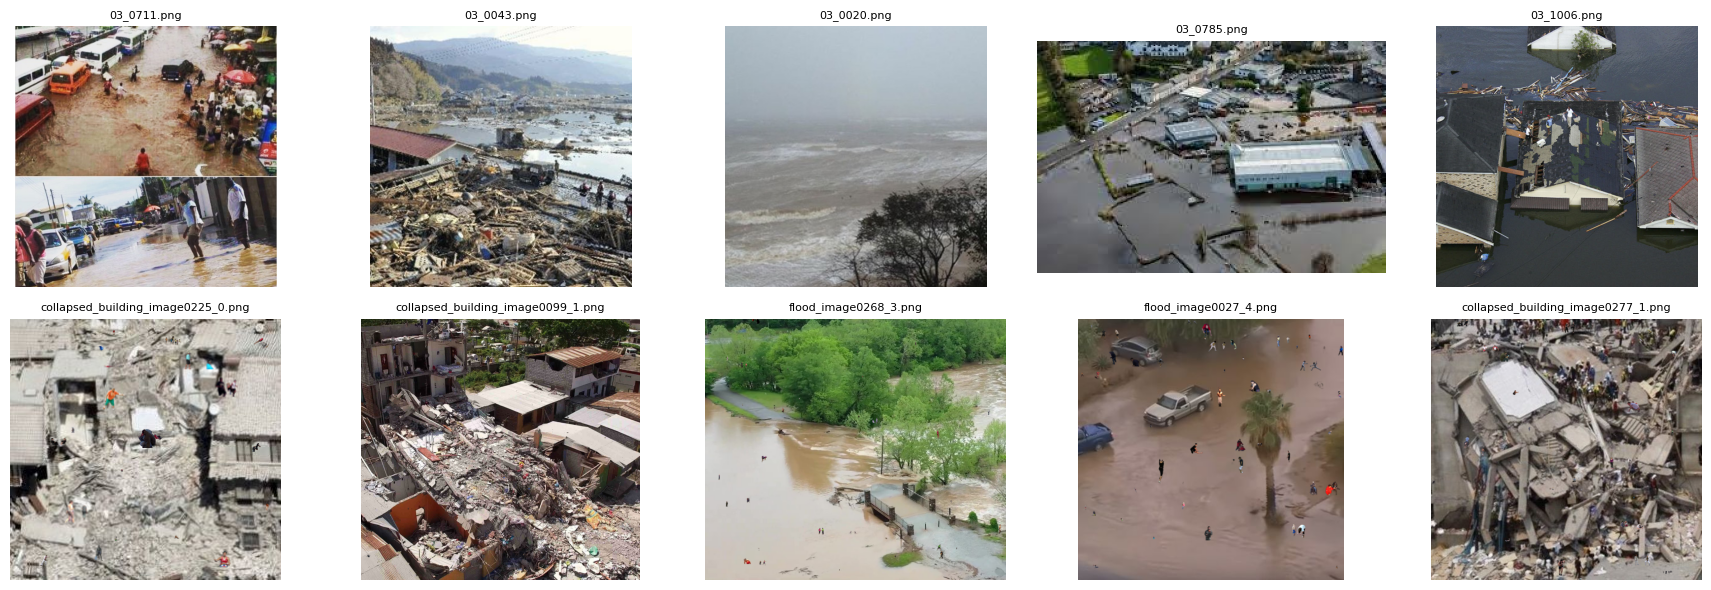

{'market_road_scene': '/kaggle/input/datasets/varpit94/disaster-images-dataset/Comprehensive Disaster Dataset(CDD)/Water_Disaster/03_0711.png', 'rescue_movement_scene': '/kaggle/input/datasets/varpit94/disaster-images-dataset/Comprehensive Disaster Dataset(CDD)/Water_Disaster/03_0043.png', 'relief_camp_photo': '/kaggle/input/datasets/varpit94/disaster-images-dataset/Comprehensive Disaster Dataset(CDD)/Water_Disaster/03_0020.png'}


In [16]:
# CELL 5 — Visual sanity check: show the selected images in a grid
# -----------------------------------------------------------------------------
def show_image_grid(paths, cols=5, figsize=(18, 6)):
    rows = (len(paths) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)
    for ax, p in zip(axes, paths):
        try:
            # Use PIL (same decoder used in is_valid_image) rather than
            # mpimg.imread — some files pass a basic header check but still
            # trip up matplotlib's stricter PNG reader; PIL is more tolerant
            # and matches what we validated against in CELL 4.
            img = Image.open(p).convert("RGB")
            ax.imshow(img)
            ax.set_title(os.path.basename(p), fontsize=8)
        except Exception as e:
            ax.set_title(f"load failed: {e}", fontsize=8)
        ax.axis("off")
    for ax in axes[len(paths):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
 
show_image_grid(selected_images)
 
# --- MANUAL STEP ---
# Look at the grid above and reassign which file plays which role in your
# scenario script (see CELL 8). Swap indices in `SCENARIO_IMAGE_ASSIGNMENT`
# below to match whichever images actually look right (e.g. one that looks
# like a street, one that looks like a tent/camp, etc.)
SCENARIO_IMAGE_ASSIGNMENT = {
    "market_road_scene": selected_images[0],
    "rescue_movement_scene": selected_images[1],
    "relief_camp_photo": selected_images[2],
    "visual_noise_1": selected_images[3],
    "visual_noise_2": selected_images[4],
}
print(SCENARIO_IMAGE_ASSIGNMENT)

In [17]:
# CELL 6 — Load and filter NCRB real missing-person records
# -----------------------------------------------------------------------------
ncrb_files = glob.glob(CONFIG["ncrb_csv_glob"])
print("NCRB files found:", ncrb_files)  # expect .../missing-people/cleandata.csv
 
ncrb_df = pd.DataFrame()
if ncrb_files:
    ncrb_df = pd.read_csv(ncrb_files[0])
    print(ncrb_df.columns.tolist())
    print(ncrb_df.head())
else:
    print("[WARN] No NCRB CSV found — check CELL 2 output; expected file is cleandata.csv.")
 
# Filter down to a small, usable slice: drop rows with missing name/age/location,
# then sample a handful. Column names below are best-guess for cleandata.csv —
# RUN THE print(ncrb_df.columns.tolist()) ABOVE FIRST and correct these three
# constants to match exactly before relying on the sample further down.
NAME_COL = "name"        # confirm exact casing/spelling against real columns
AGE_COL = "age"
LOCATION_COL = "state"   # or 'district' / 'city' — confirm against real columns
 
if not ncrb_df.empty:
    cols_present = [c for c in [NAME_COL, AGE_COL, LOCATION_COL] if c in ncrb_df.columns]
    ncrb_clean = ncrb_df.dropna(subset=cols_present) if cols_present else ncrb_df.dropna(how="all")
    ncrb_sample = ncrb_clean.sample(
        min(CONFIG["n_named_records"], len(ncrb_clean)), random_state=42
    )
    print(ncrb_sample)
else:
    ncrb_sample = pd.DataFrame()

NCRB files found: ['/kaggle/input/datasets/arjoonn/missing-people/cleandata.csv']
['Name', 'Gender', 'Relative', 'Address', 'AgeStart', 'AgeEnd', 'HeightStart', 'HeightEnd', 'Built', 'Date', 'Dist', 'State']
         Name  Gender        Relative  \
0       JYOTI  Female           GEETA   
1    ABHISHEK    Male    MUKE SHKUMAR   
2         NaN    Male    RAJE SHKUMAR   
3  JAIPRAKASH    Male   KAMA LKISHORE   
4      SADDAM    Male          MUNN A   

                                             Address  AgeStart  AgeEnd  \
0  ,  , E 129 A SHOK NAGAR PRIDAY MARKET CHOWK DE...        16      17   
1  , , JHUGGI NO. N- 78/102, SHIVANAND SCHOOL SEW...        19      20   
2  , NO, 79, GALI NO. 3 KONDLI DELHI NEW A SHOK N...        19      20   
3  , , 15/286, KALYANPURI DELHI KALYA NPURI EAST ...        24      25   
4  , , 19-20, KABOOTAR MARKET WELCOM DELHI WELCO ...        21      22   

   HeightStart  HeightEnd         Built  Date                       Dist  \
0        122.0      183.

In [18]:
# CELL 7 — Load and filter synthetic person records (for bulk padding)
# -----------------------------------------------------------------------------
# synthetic_person_csv_glob now points directly at person_10000.csv (the
# smallest of the 7 size variants — all are the same synthetic data, just
# resampled at different row counts, so smallest is fine for our ~20 rows).
synth_path = CONFIG["synthetic_person_csv_glob"]
print("Synthetic person file:", synth_path, "| exists:", os.path.isfile(synth_path))
 
synth_df = pd.DataFrame()
if os.path.isfile(synth_path):
    synth_df = pd.read_csv(synth_path, nrows=5000)  # cap rows read from disk regardless
    print(synth_df.columns.tolist())
    print(synth_df.head())
else:
    print("[WARN] person_10000.csv not found — check CELL 2 output for the exact filename.")
 
if not synth_df.empty:
    synth_sample = synth_df.sample(
        min(CONFIG["n_synthetic_padding"], len(synth_df)), random_state=42
    )
else:
    synth_sample = pd.DataFrame()
 
print(f"Selected {len(synth_sample)} synthetic filler records")

Synthetic person file: /kaggle/input/datasets/swainproject/synthetic-data-person/person_10000.csv | exists: True
['person_id', 'firstname', 'lastname', 'gender', 'age', 'street', 'streetnumber', 'address_unit', 'postalcode', 'city', 'phone', 'email']
   person_id firstname lastname  gender  age         street  streetnumber  \
0          1   Gabriel   Pellum   Other   31    Day Station          1346   
1          2   Nicolas   Pelliu  Female   46   Isaac Unions          2264   
2          3      Paul   Powers  Female   55  Stewart Ranch          2202   
3          4    Regina   Pellum  Female   77  King Parkways           568   
4          5     Shawn   Miller  Female   88   David Manors          2025   

  address_unit  postalcode              city            phone  \
0   Building A       39560        Lake Barry  +1-575-800-4337   
1   Ste. 33418       50616  East Michaeltown   1-726-911-1758   
2     Apt. 461       34640       Stewartberg     712-984-7245   
3  Building C4       71379

In [19]:
# CELL 8 — Build the LOST SIGNAL scenario
# =============================================================================
# Baseline:
#   25 evidence items
#   20 text + 5 photos
#
# Intended strongest chain:
# Priya Sen -> Market Road -> Evac Unit 3 -> Govt School Shelter -> P. Sen
#
# Relief Camp 7 = competing false trail
# EV_LIVE = held out for live demo
# =============================================================================

MISSING_PERSON = {
    "id": "MP001",
    "name": "Priya Sen",
    "age": 19,
    "last_seen_location": "Market Road",
    "last_seen_time": "2026-07-20T16:10:00",
    "reported_by": "family",
    "description": "wearing a blue kurta",
}


EVIDENCE_ITEMS = [

    # =========================
    # CORE SIGNAL
    # =========================

    {
        "id": "EV001",
        "type": "witness_message",
        "raw_input":
            "saw a girl matching description near Market Road around 4pm, "
            "she seemed scared",
        "timestamp_hint": "2026-07-20T16:05:00",
        "location_hint": "Market Road",
        "ground_truth_relevance": "high",
    },

    {
        "id": "EV002",
        "type": "rescue_log",
        "raw_input":
            "Evac unit 3 moved ~15 evacuees from Market Rd area "
            "to Govt School shelter, 16:30",
        "timestamp_hint": "2026-07-20T16:30:00",
        "location_hint": "Govt School Shelter",
        "ground_truth_relevance": "high",
    },

    {
        "id": "EV003",
        "type": "shelter_register",
        "raw_input":
            "Entry: P. Sen, F, ~19-20yo, admitted 17:00, "
            "Govt School Shelter",
        "timestamp_hint": "2026-07-20T17:00:00",
        "location_hint": "Govt School Shelter",
        "ground_truth_relevance": "high",
    },

    # =========================
    # PHOTO 1 — MARKET ROAD
    # =========================

    {
        "id": "EV004",
        "type": "photo",
        "raw_input":
            SCENARIO_IMAGE_ASSIGNMENT.get("market_road_scene"),
        "timestamp_hint": "2026-07-20T16:15:00",
        "location_hint": "Market Road",
        "ground_truth_relevance": "medium",
    },

    # =========================
    # CAMP 7 HEARSAY
    # =========================

    {
        "id": "EV005",
        "type": "witness_message",
        "raw_input":
            "someone said a girl was taken to Camp 7 not the school, "
            "not sure though",
        "timestamp_hint": "2026-07-20T17:30:00",
        "location_hint": "Relief Camp 7",
        "ground_truth_relevance": "low_contradiction",
    },

    # =========================
    # PHOTO 2 — RESCUE
    # =========================

    {
        "id": "EV006",
        "type": "photo",
        "raw_input":
            SCENARIO_IMAGE_ASSIGNMENT.get("rescue_movement_scene"),
        "timestamp_hint": "2026-07-20T16:35:00",
        "location_hint": "Market Road",
        "ground_truth_relevance": "medium",
    },

    # =========================
    # SUPPORTING SIGNAL
    # =========================

    {
        "id": "EV007",
        "type": "rescue_log",
        "raw_input":
            "Unit 3 departure manifest: Market Road pickup completed; "
            "destination Govt School Shelter",
        "timestamp_hint": "2026-07-20T16:34:00",
        "location_hint": "Market Road",
        "ground_truth_relevance": "high_support",
    },

    {
        "id": "EV008",
        "type": "witness_message",
        "raw_input":
            "volunteer remembers a college-age girl in blue arriving "
            "with the Market Road evacuation group",
        "timestamp_hint": "2026-07-20T16:55:00",
        "location_hint": "Govt School Shelter",
        "ground_truth_relevance": "medium",
    },

    # =========================
    # NEAR-MATCH DISTRACTORS
    # =========================

    {
        "id": "EV009",
        "type": "shelter_register",
        "raw_input":
            "Entry: P. Saha, F, 20yo, admitted 17:15, "
            "Community Hall Shelter",
        "timestamp_hint": "2026-07-20T17:15:00",
        "location_hint": "Community Hall Shelter",
        "ground_truth_relevance": "noise_near_match",
    },

    {
        "id": "EV010",
        "type": "witness_message",
        "raw_input":
            "Priyanka Sen, approximately 21, was asking volunteers "
            "for directions near Railway Colony",
        "timestamp_hint": "2026-07-20T16:40:00",
        "location_hint": "Railway Colony",
        "ground_truth_relevance": "noise_near_match",
    },

    {
        "id": "EV011",
        "type": "shelter_register",
        "raw_input":
            "Entry: Riya Sen, F, 18yo, admitted 16:50, "
            "College Relief Centre",
        "timestamp_hint": "2026-07-20T16:50:00",
        "location_hint": "College Relief Centre",
        "ground_truth_relevance": "noise_near_match",
    },

    {
        "id": "EV012",
        "type": "witness_message",
        "raw_input":
            "girl around 19 wearing blue was seen near Bus Stand "
            "with two family members",
        "timestamp_hint": "2026-07-20T16:20:00",
        "location_hint": "Bus Stand",
        "ground_truth_relevance": "noise_near_match",
    },

    {
        "id": "EV013",
        "type": "shelter_register",
        "raw_input":
            "Entry: Priya Das, F, 19yo, admitted 17:10, "
            "Relief Camp 7",
        "timestamp_hint": "2026-07-20T17:10:00",
        "location_hint": "Relief Camp 7",
        "ground_truth_relevance": "noise_near_match",
    },

    # =========================
    # PHOTO 3 — CAMP 7
    # =========================

    {
        "id": "EV014",
        "type": "photo",
        "raw_input":
            SCENARIO_IMAGE_ASSIGNMENT.get("relief_camp_photo"),
        "timestamp_hint": "2026-07-20T18:00:00",
        "location_hint": "Relief Camp 7",
        "ground_truth_relevance": "low_contradiction",
    },

    # =========================
    # CAMP 7 FALSE TRAIL
    # =========================

    {
        "id": "EV015",
        "type": "rescue_log",
        "raw_input":
            "Camp 7 received twelve evacuees from Riverside and Bus Stand; "
            "no Market Road pickup recorded on this trip",
        "timestamp_hint": "2026-07-20T17:05:00",
        "location_hint": "Relief Camp 7",
        "ground_truth_relevance": "contradiction_resolution",
    },

    {
        "id": "EV016",
        "type": "witness_message",
        "raw_input":
            "caller thought she recognised Priya at Camp 7 but only "
            "saw the person from a distance and was unsure",
        "timestamp_hint": "2026-07-20T18:05:00",
        "location_hint": "Relief Camp 7",
        "ground_truth_relevance": "low_contradiction",
    },

    # =========================
    # GENERAL DISASTER NOISE
    # =========================

    {
        "id": "EV017",
        "type": "rescue_log",
        "raw_input":
            "Boat team rescued six residents from Riverside Lane "
            "and transported them to Community Hall",
        "timestamp_hint": "2026-07-20T16:15:00",
        "location_hint": "Riverside Lane",
        "ground_truth_relevance": "noise",
    },

    {
        "id": "EV018",
        "type": "shelter_register",
        "raw_input":
            "Entry: Amit Roy, M, 47yo, admitted 16:42, "
            "Govt School Shelter",
        "timestamp_hint": "2026-07-20T16:42:00",
        "location_hint": "Govt School Shelter",
        "ground_truth_relevance": "noise",
    },

    {
        "id": "EV019",
        "type": "witness_message",
        "raw_input":
            "elderly man separated from family near Temple Road "
            "during evacuation",
        "timestamp_hint": "2026-07-20T16:28:00",
        "location_hint": "Temple Road",
        "ground_truth_relevance": "noise",
    },

    {
        "id": "EV020",
        "type": "rescue_log",
        "raw_input":
            "Ambulance 2 transported injured male from Station Road "
            "to District Hospital",
        "timestamp_hint": "2026-07-20T16:48:00",
        "location_hint": "Station Road",
        "ground_truth_relevance": "noise",
    },

    # =========================
    # PHOTO 4 — VISUAL NOISE
    # =========================

    {
        "id": "EV021",
        "type": "photo",
        "raw_input":
            SCENARIO_IMAGE_ASSIGNMENT.get("visual_noise_1"),
        "timestamp_hint": "2026-07-20T17:25:00",
        "location_hint": "Riverside Sector",
        "ground_truth_relevance": "noise",
    },

    # =========================
    # MORE TEXT NOISE
    # =========================

    {
        "id": "EV022",
        "type": "witness_message",
        "raw_input":
            "two teenagers were waiting for relatives outside "
            "College Relief Centre",
        "timestamp_hint": "2026-07-20T17:40:00",
        "location_hint": "College Relief Centre",
        "ground_truth_relevance": "noise",
    },

    {
        "id": "EV023",
        "type": "rescue_log",
        "raw_input":
            "Road access between Bus Stand and Riverside temporarily "
            "closed because of rising floodwater",
        "timestamp_hint": "2026-07-20T16:38:00",
        "location_hint": "Bus Stand",
        "ground_truth_relevance": "noise",
    },

    {
        "id": "EV024",
        "type": "shelter_register",
        "raw_input":
            "Entry: S. Sen, M, 52yo, admitted 18:02, "
            "Relief Camp 7",
        "timestamp_hint": "2026-07-20T18:02:00",
        "location_hint": "Relief Camp 7",
        "ground_truth_relevance": "noise_name_collision",
    },

    # =========================
    # PHOTO 5 — VISUAL NOISE
    # =========================

    {
        "id": "EV025",
        "type": "photo",
        "raw_input":
            SCENARIO_IMAGE_ASSIGNMENT.get("visual_noise_2"),
        "timestamp_hint": "2026-07-20T17:50:00",
        "location_hint": "Outer Flood Zone",
        "ground_truth_relevance": "noise",
    },
]


# =============================================================================
# LIVE DEMO CLUE
# Kept OUT of EVIDENCE_ITEMS.
# =============================================================================

LIVE_DEMO_CLUE = {
    "id": "EV_LIVE",
    "type": "witness_message",
    "raw_input":
        "Priya was carrying a yellow umbrella when we saw her "
        "near Market Road",
    "timestamp_hint": "2026-07-20T16:07:00",
    "location_hint": "Market Road",
    "ground_truth_relevance": "high",
}


# Simple summary — harmless even if teammate runs it later.

print(f"{len(EVIDENCE_ITEMS)} baseline evidence items defined.")
print(
    "Text evidence:",
    len([x for x in EVIDENCE_ITEMS if x["type"] != "photo"])
)
print(
    "Photo evidence:",
    len([x for x in EVIDENCE_ITEMS if x["type"] == "photo"])
)
print("Live clue held out:", LIVE_DEMO_CLUE["id"])

5 baseline evidence items defined. Pad this list to ~25-30 before the real run.


In [20]:
# CELL 9 — Model paths and memory-safe model loaders
# =============================================================================
# Gemma 4 E4B-IT  : text reasoning / structured extraction
# PaliGemma 2 MIX : visual perception
#
# IMPORTANT:
# The two models are NOT kept in GPU memory simultaneously.
# =============================================================================

import os
import gc
import torch

from transformers import (
    AutoProcessor,
    AutoModelForMultimodalLM,
    AutoModelForImageTextToText,
)


# =============================================================================
# MODEL PATHS
# =============================================================================

TEXT_MODEL_PATH = (
    "/kaggle/input/models/google/gemma-4/"
    "transformers/gemma-4-e4b-it/1"
)

VISION_MODEL_PATH = (
    "/kaggle/input/models/google/paligemma-2/"
    "transformers/paligemma2-3b-mix-448/1"
)


print("Model paths:")

print(
    "Gemma 4 E4B-IT :",
    TEXT_MODEL_PATH,
    "| exists:",
    os.path.isdir(TEXT_MODEL_PATH)
)

print(
    "PaliGemma 2 MIX:",
    VISION_MODEL_PATH,
    "| exists:",
    os.path.isdir(VISION_MODEL_PATH)
)


if not os.path.isdir(TEXT_MODEL_PATH):
    raise FileNotFoundError(
        f"Gemma 4 model not found:\n{TEXT_MODEL_PATH}"
    )

if not os.path.isdir(VISION_MODEL_PATH):
    raise FileNotFoundError(
        f"PaliGemma 2 MIX model not found:\n{VISION_MODEL_PATH}"
    )


# =============================================================================
# GLOBAL MODEL REFERENCES
# =============================================================================

_text_model = None
_text_processor = None

_vision_model = None
_vision_processor = None


# =============================================================================
# GPU MEMORY HELPER
# =============================================================================

def print_gpu_memory():

    if not torch.cuda.is_available():
        print("CUDA unavailable.")
        return

    for i in range(torch.cuda.device_count()):

        free, total = torch.cuda.mem_get_info(i)

        print(
            f"GPU {i}: "
            f"{free / 1024**3:.2f} GB free / "
            f"{total / 1024**3:.2f} GB total"
        )


# =============================================================================
# GEMMA 4 LOADER
# =============================================================================

def load_text_model():

    global _text_model
    global _text_processor

    if _text_model is not None:
        return _text_model, _text_processor

    print("\nLoading Gemma 4 E4B-IT...")

    _text_processor = AutoProcessor.from_pretrained(
        TEXT_MODEL_PATH
    )

    # Memory limits leave room for Accelerate/offloading.
    max_memory = {
        0: "10GiB",
        1: "10GiB",
        "cpu": "30GiB"
    }

    _text_model = AutoModelForMultimodalLM.from_pretrained(
        TEXT_MODEL_PATH,
        dtype=torch.bfloat16,
        device_map="auto",
        max_memory=max_memory,
        low_cpu_mem_usage=True
    )

    _text_model.eval()

    print("Gemma 4 E4B-IT loaded.")
    print_gpu_memory()

    return _text_model, _text_processor


# =============================================================================
# PALIGEMMA 2 MIX LOADER
# =============================================================================

def load_vision_model():

    global _vision_model
    global _vision_processor

    if _vision_model is not None:
        return _vision_model, _vision_processor

    print("\nLoading PaliGemma 2 3B MIX 448...")

    _vision_processor = AutoProcessor.from_pretrained(
        VISION_MODEL_PATH
    )

    _vision_model = AutoModelForImageTextToText.from_pretrained(
        VISION_MODEL_PATH,
        dtype=torch.bfloat16,
        device_map="auto",
        low_cpu_mem_usage=True
    )

    _vision_model.eval()

    print("PaliGemma 2 MIX loaded.")
    print_gpu_memory()

    return _vision_model, _vision_processor


# =============================================================================
# CLEANUP
# =============================================================================

def clear_model_memory():

    gc.collect()

    if torch.cuda.is_available():

        torch.cuda.empty_cache()

        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass


print("\nCell 9 ready.")
print("Models are NOT loaded yet.")
print_gpu_memory()

Model paths:
Gemma 4 E4B-IT : /kaggle/input/models/google/gemma-4/transformers/gemma-4-e4b-it/1 | exists: True
PaliGemma 2 MIX: /kaggle/input/models/google/paligemma-2/transformers/paligemma2-3b-mix-448/1 | exists: True

Cell 9 ready.
Models are NOT loaded yet.
GPU 0: 14.46 GB free / 14.56 GB total
GPU 1: 14.46 GB free / 14.56 GB total


In [21]:
# CELL 10 — LOST SIGNAL: Multimodal Evidence Extraction
# =============================================================================
#
# FINAL ARCHITECTURE
#
# TEXT:
#   Text evidence
#       -> Gemma 4 E4B-IT
#       -> Structured JSON clue
#
# IMAGE:
#   Disaster image
#       -> PaliGemma 2 3B MIX 448
#       -> Grounded visual evidence description
#       -> Gemma 4 E4B-IT
#       -> Structured JSON clue
#
# PaliGemma = Visual perception
# Gemma 4   = Reasoning + normalization + structured extraction
#
# Models are loaded/unloaded sequentially to avoid GPU OOM.
# =============================================================================


import re
import json
import gc
import torch

from PIL import Image


# =============================================================================
# 1. REQUIRED OUTPUT SCHEMA
# =============================================================================

CLUE_KEYS = [
    "name_guess",
    "age_guess",
    "location",
    "time",
    "description",
    "source_type",
    "confidence"
]


def empty_clue(source_type):

    return {
        "name_guess": None,
        "age_guess": None,
        "location": None,
        "time": None,
        "description": None,
        "source_type": source_type,
        "confidence": 0.0
    }


# =============================================================================
# 2. SAFE JSON PARSER
# =============================================================================

def safe_json_parse(raw_text, source_type):

    fallback = empty_clue(source_type)

    if raw_text is None:
        return fallback

    cleaned = str(raw_text).strip()

    # Remove possible Markdown fences
    cleaned = re.sub(
        r"```(?:json)?",
        "",
        cleaned,
        flags=re.IGNORECASE
    )

    cleaned = cleaned.replace("```", "").strip()

    result = None

    # -------------------------------------------------------------------------
    # Attempt 1 — Entire response is JSON
    # -------------------------------------------------------------------------

    try:

        candidate = json.loads(cleaned)

        if isinstance(candidate, dict):
            result = candidate

    except Exception:
        pass


    # -------------------------------------------------------------------------
    # Attempt 2 — Find JSON object inside response
    # -------------------------------------------------------------------------

    if result is None:

        start = cleaned.find("{")
        end = cleaned.rfind("}")

        if (
            start != -1
            and end != -1
            and end > start
        ):

            candidate_text = cleaned[start:end + 1]

            try:

                candidate = json.loads(candidate_text)

                if isinstance(candidate, dict):
                    result = candidate

            except Exception:
                pass


    # -------------------------------------------------------------------------
    # Parsing failed
    # -------------------------------------------------------------------------

    if result is None:

        print(
            "[WARN] Gemma output could not be parsed as JSON."
        )

        print(
            "Raw output:",
            cleaned[:400]
        )

        return fallback


    # -------------------------------------------------------------------------
    # Enforce exact schema
    # -------------------------------------------------------------------------

    normalized = fallback.copy()

    for key in CLUE_KEYS:

        if key in result:
            normalized[key] = result[key]

    # Source type comes from our pipeline, not model inference
    normalized["source_type"] = source_type


    # -------------------------------------------------------------------------
    # Normalize confidence
    # -------------------------------------------------------------------------

    try:

        confidence = float(
            normalized["confidence"]
        )

        confidence = max(
            0.0,
            min(1.0, confidence)
        )

        normalized["confidence"] = confidence

    except Exception:

        normalized["confidence"] = 0.0


    # -------------------------------------------------------------------------
    # Normalize age
    # -------------------------------------------------------------------------

    age = normalized["age_guess"]

    if age is not None:

        try:

            if isinstance(age, bool):
                normalized["age_guess"] = None

            elif isinstance(age, (int, float)):
                normalized["age_guess"] = int(age)

            elif isinstance(age, str):

                stripped = age.strip()

                if stripped.isdigit():
                    normalized["age_guess"] = int(stripped)

                else:
                    normalized["age_guess"] = None

            else:
                normalized["age_guess"] = None

        except Exception:
            normalized["age_guess"] = None


    return normalized


# =============================================================================
# 3. GEMMA 4 — EVIDENCE REASONING
# =============================================================================

def structure_with_gemma(
    evidence_text,
    source_type,
    timestamp_hint=None,
    location_hint=None,
    evidence_origin="direct"
):

    model, processor = load_text_model()


    # -------------------------------------------------------------------------
    # Tell Gemma whether evidence came directly from text or from PaliGemma.
    # -------------------------------------------------------------------------

    if evidence_origin == "vision":

        origin_note = """
IMPORTANT SOURCE NOTE:

The evidence below is a machine-generated visual observation produced
by a vision model from an image.

Treat the description as an observation rather than an independently
verified fact.

Do NOT:
- add visual details absent from the observation
- convert uncertain visual observations into definite facts
- infer identity from appearance
- infer an exact age from appearance
- infer an exact location from scenery alone
"""

    else:

        origin_note = """
IMPORTANT SOURCE NOTE:

The evidence below comes directly from a textual evidence source.

Extract only information supported by that evidence.
"""


    # -------------------------------------------------------------------------
    # Main Gemma 4 reasoning prompt
    # -------------------------------------------------------------------------

    prompt = f"""
You are the evidence reasoning and normalization engine for LOST SIGNAL,
an AI-assisted disaster missing-person search and reunification system.

Your task is to convert ONE piece of evidence into ONE structured clue.

You are performing EVIDENCE EXTRACTION.

You are NOT performing:
- identity confirmation
- face recognition
- person matching
- missing-person probability estimation


================ EVIDENCE ================

{evidence_text}


================ SOURCE CONTEXT ================

Source type:
{source_type}

Timestamp metadata hint:
{timestamp_hint}

Location metadata hint:
{location_hint}


{origin_note}


================ EXTRACTION RULES ================

1. EVIDENCE GROUNDING

Extract only information explicitly stated or clearly supported by the
provided evidence.

Never invent, complete or assume missing information.


2. IDENTITY

Never conclude that the subject is the missing person.

Never identify a person from physical appearance alone.


3. NAME

Preserve names exactly as provided.

Preserve:
- partial names
- initials
- uncertain fragments

Never:
- expand initials
- complete partial names
- guess a name from appearance

If no name is supported, use null.


4. AGE

age_guess must contain a numeric age ONLY when an age is explicitly
stated or clearly documented.

Examples:

"17-year-old boy"
-> 17

"age 42"
-> 42

"young adult"
-> null

"appears elderly"
-> null

Never convert a visual age group into an exact numeric age.


5. LOCATION

Prefer a location explicitly stated or clearly documented in the
evidence.

If the evidence itself contains no location, the location metadata hint
may be used when available.

Do not infer a precise geographic location from scenery alone.


6. TIME

Prefer a time explicitly stated or documented in the evidence.

If no explicit time exists, the timestamp metadata hint may be used when
available.


7. MULTIPLE PEOPLE

Never combine characteristics belonging to different people.

If one clear primary subject exists, structure the clue around that
subject.

If there is no safe primary subject, keep the description general rather
than merging identities.


8. DESCRIPTION

Preserve useful missing-person search and reunification evidence when
supported.

Useful details may include:

- clothing
- clothing colors
- approximate visual age group
- visible physical characteristics
- visible injuries
- physical condition
- footwear
- accessories
- bags
- belongings
- distinctive objects
- actions
- posture
- movement
- vehicles
- rescue activity
- emergency equipment
- buildings
- shelters
- roads
- landmarks
- disaster damage
- flooding
- debris
- fire
- environmental conditions
- readable signs
- readable labels
- visible numbers
- other clearly readable text

Keep the description concise, factual and evidence-focused.

Do not add speculation.


================ CONFIDENCE ================

confidence represents ONLY how reliably the structured clue is supported
by the supplied evidence.

It does NOT represent:

- probability that this is the missing person
- probability of an identity match
- importance of the clue


Use this scale:

0.90 - 1.00
Explicit, clear and unambiguous evidence.

0.70 - 0.89
Strongly supported evidence with minor uncertainty.

0.50 - 0.69
Useful but incomplete or moderately uncertain evidence.

0.30 - 0.49
Vague or weakly supported evidence.

0.00 - 0.29
Very little reliable information.


================ OUTPUT REQUIREMENTS ================

Return ONLY ONE valid JSON object.

Do NOT return:

- Markdown
- code fences
- explanations
- analysis
- comments
- introductory text
- text after the JSON


Use EXACTLY these seven keys:

{{
  "name_guess": null,
  "age_guess": null,
  "location": null,
  "time": null,
  "description": null,
  "source_type": "{source_type}",
  "confidence": 0.0
}}
""".strip()


    # -------------------------------------------------------------------------
    # Gemma chat formatting
    # -------------------------------------------------------------------------

    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": prompt
                }
            ]
        }
    ]


    inputs = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt"
    )


    # -------------------------------------------------------------------------
    # Put inputs on the device containing the model's input embeddings.
    # -------------------------------------------------------------------------

    input_device = (
        model.get_input_embeddings()
        .weight.device
    )


    inputs = {

        key: (
            value.to(input_device)
            if torch.is_tensor(value)
            else value
        )

        for key, value in inputs.items()
    }


    # -------------------------------------------------------------------------
    # Generate
    # -------------------------------------------------------------------------

    with torch.inference_mode():

        output = model.generate(
            **inputs,
            max_new_tokens=220,
            do_sample=False
        )


    input_length = (
        inputs["input_ids"].shape[-1]
    )


    generated_tokens = (
        output[0][input_length:]
    )


    raw_text = processor.decode(
        generated_tokens,
        skip_special_tokens=True
    ).strip()


    return safe_json_parse(
        raw_text,
        source_type
    )


# =============================================================================
# 4. TEXT EVIDENCE -> GEMMA 4
# =============================================================================

def extract_clue_from_text(evidence_item):

    return structure_with_gemma(

        evidence_text=(
            evidence_item["raw_input"]
        ),

        source_type=(
            evidence_item["type"]
        ),

        timestamp_hint=(
            evidence_item.get(
                "timestamp_hint"
            )
        ),

        location_hint=(
            evidence_item.get(
                "location_hint"
            )
        ),

        evidence_origin="direct"
    )


# =============================================================================
# 5. PALIGEMMA 2 MIX — VISUAL PERCEPTION
# =============================================================================

def describe_image_with_paligemma(
    evidence_item
):

    model, processor = load_vision_model()


    # -------------------------------------------------------------------------
    # Load image
    # -------------------------------------------------------------------------

    image_path = evidence_item["raw_input"]

    image = Image.open(
        image_path
    ).convert("RGB")


    # -------------------------------------------------------------------------
    # PALIGEMMA PROMPT
    #
    # IMPORTANT:
    # PaliGemma is NOT asked for JSON.
    # It is NOT asked to perform matching or identity reasoning.
    #
    # Its only task is grounded visual observation.
    # -------------------------------------------------------------------------

    prompt = "<image>caption en"


    # -------------------------------------------------------------------------
    # Processor
    # -------------------------------------------------------------------------

    inputs = processor(
        images=image,
        text=prompt,
        return_tensors="pt"
    )


    input_device = (
        model.get_input_embeddings()
        .weight.device
    )


    inputs = {

        key: (
            value.to(input_device)
            if torch.is_tensor(value)
            else value
        )

        for key, value in inputs.items()
    }


    # -------------------------------------------------------------------------
    # Generate visual description
    # -------------------------------------------------------------------------

    with torch.inference_mode():

        output = model.generate(
            **inputs,
            max_new_tokens=200,
            do_sample=False
        )


    input_length = (
        inputs["input_ids"].shape[-1]
    )


    generated_tokens = (
        output[0][input_length:]
    )


    description = processor.decode(
        generated_tokens,
        skip_special_tokens=True
    ).strip()


    return description


# =============================================================================
# 6. GPU MEMORY MANAGEMENT
# =============================================================================

def clear_gpu_cache():

    gc.collect()

    if torch.cuda.is_available():

        torch.cuda.empty_cache()

        try:
            torch.cuda.ipc_collect()

        except Exception:
            pass


# =============================================================================
# 7. UNLOAD GEMMA 4
# =============================================================================

def unload_text_model():

    global _text_model
    global _text_processor

    print(
        "\nUnloading Gemma 4..."
    )

    # IMPORTANT:
    # Do NOT call model.to("cpu").
    #
    # Gemma is dispatched using Accelerate hooks and moving it manually
    # caused the warning we saw earlier.

    _text_model = None
    _text_processor = None

    clear_gpu_cache()

    print(
        "Gemma 4 unloaded."
    )


# =============================================================================
# 8. UNLOAD PALIGEMMA
# =============================================================================

def unload_vision_model():

    global _vision_model
    global _vision_processor

    print(
        "\nUnloading PaliGemma 2..."
    )

    _vision_model = None
    _vision_processor = None

    clear_gpu_cache()

    print(
        "PaliGemma 2 unloaded."
    )


# =============================================================================
# 9. GPU MEMORY DISPLAY
# =============================================================================

def show_gpu_memory():

    if not torch.cuda.is_available():

        print(
            "CUDA unavailable."
        )

        return


    for i in range(
        torch.cuda.device_count()
    ):

        free, total = (
            torch.cuda.mem_get_info(i)
        )

        print(

            f"GPU {i}: "
            f"{free / 1024**3:.2f} GB free / "
            f"{total / 1024**3:.2f} GB total"

        )


# =============================================================================
# 10. COMPLETE MULTIMODAL EXTRACTION PIPELINE
# =============================================================================

def extract_all_evidence(
    evidence_items
):

    structured_by_id = {}

    visual_descriptions = {}


    # =========================================================================
    # PHASE 1
    #
    # TEXT -> GEMMA 4 -> STRUCTURED CLUE
    # =========================================================================

    text_items = [

        item

        for item in evidence_items

        if item["type"] != "photo"

    ]


    print(
        "=" * 72
    )

    print(
        "PHASE 1 — TEXT EVIDENCE | GEMMA 4 E4B-IT"
    )

    print(
        "=" * 72
    )


    print(
        f"Processing "
        f"{len(text_items)} "
        f"text evidence item(s)."
    )


    for index, item in enumerate(
        text_items,
        start=1
    ):

        print(
            f"[{index}/{len(text_items)}] "
            f"{item['id']}"
        )


        clue = extract_clue_from_text(
            item
        )


        clue["_evidence_id"] = (
            item["id"]
        )

        clue["_source_type"] = (
            item["type"]
        )


        structured_by_id[
            item["id"]
        ] = clue


    print(
        "Text evidence extraction complete."
    )


    # -------------------------------------------------------------------------
    # Gemma must leave memory before PaliGemma loads.
    # -------------------------------------------------------------------------

    unload_text_model()

    show_gpu_memory()


    # =========================================================================
    # PHASE 2
    #
    # IMAGE -> PALIGEMMA -> VISUAL EVIDENCE
    # =========================================================================

    photo_items = [

        item

        for item in evidence_items

        if item["type"] == "photo"

    ]


    print()

    print(
        "=" * 72
    )

    print(
        "PHASE 2 — VISUAL PERCEPTION | PALIGEMMA 2 MIX"
    )

    print(
        "=" * 72
    )


    print(
        f"Processing "
        f"{len(photo_items)} "
        f"photo evidence item(s)."
    )


    for index, item in enumerate(
        photo_items,
        start=1
    ):

        print(
            f"[{index}/{len(photo_items)}] "
            f"{item['id']}"
        )


        description = (
            describe_image_with_paligemma(
                item
            )
        )


        visual_descriptions[
            item["id"]
        ] = description


        print()

        print(
            "PaliGemma visual evidence:"
        )

        print(
            description
        )

        print()


    print(
        "Visual perception complete."
    )


    # -------------------------------------------------------------------------
    # PaliGemma must leave memory before Gemma reloads.
    # -------------------------------------------------------------------------

    unload_vision_model()

    show_gpu_memory()


    # =========================================================================
    # PHASE 3
    #
    # PALIGEMMA DESCRIPTION -> GEMMA 4 -> STRUCTURED CLUE
    # =========================================================================

    if photo_items:

        print()

        print(
            "=" * 72
        )

        print(
            "PHASE 3 — VISUAL EVIDENCE REASONING | GEMMA 4 E4B-IT"
        )

        print(
            "=" * 72
        )


        for index, item in enumerate(
            photo_items,
            start=1
        ):

            print(
                f"[{index}/{len(photo_items)}] "
                f"{item['id']}"
            )


            visual_description = (
                visual_descriptions[
                    item["id"]
                ]
            )


            clue = structure_with_gemma(

                evidence_text=(
                    visual_description
                ),

                source_type="photo",

                timestamp_hint=(
                    item.get(
                        "timestamp_hint"
                    )
                ),

                location_hint=(
                    item.get(
                        "location_hint"
                    )
                ),

                evidence_origin="vision"
            )


            clue["_evidence_id"] = (
                item["id"]
            )

            clue["_source_type"] = (
                "photo"
            )


            # Preserve PaliGemma's raw visual observation.
            #
            # This is useful for:
            # - explainability
            # - debugging
            # - hackathon demo transparency

            clue["_visual_description"] = (
                visual_description
            )


            structured_by_id[
                item["id"]
            ] = clue


        print(
            "Visual evidence reasoning complete."
        )


    # =========================================================================
    # RESTORE ORIGINAL EVIDENCE ORDER
    # =========================================================================

    structured_clues = [

        structured_by_id[
            item["id"]
        ]

        for item in evidence_items

    ]


    print()

    print(
        "=" * 72
    )

    print(
        "ALL EVIDENCE EXTRACTION COMPLETE"
    )

    print(
        "=" * 72
    )


    return structured_clues


# =============================================================================
# 11. CELL READY
# =============================================================================

print(
    "Cell 10 ready."
)

print(
    "Multimodal evidence pipeline functions loaded."
)

print(
    "Full extraction has NOT been started."
)


# =============================================================================
# DO NOT UNCOMMENT YET
# =============================================================================

# structured_clues = extract_all_evidence(EVIDENCE_ITEMS)

Cell 10 ready.
Multimodal evidence pipeline functions loaded.
Full extraction has NOT been started.


In [22]:
structured_clues = extract_all_evidence(EVIDENCE_ITEMS)

PHASE 1 — TEXT EVIDENCE | GEMMA 4 E4B-IT
Processing 4 text evidence item(s).
[1/4] EV001

Loading Gemma 4 E4B-IT...


Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.


Gemma 4 E4B-IT loaded.
GPU 0: 12.19 GB free / 14.56 GB total
GPU 1: 7.80 GB free / 14.56 GB total
[2/4] EV002
[3/4] EV003
[4/4] EV005
Text evidence extraction complete.

Unloading Gemma 4...
Gemma 4 unloaded.
GPU 0: 14.41 GB free / 14.56 GB total
GPU 1: 14.41 GB free / 14.56 GB total

PHASE 2 — VISUAL PERCEPTION | PALIGEMMA 2 MIX
Processing 1 photo evidence item(s).
[1/1] EV004

Loading PaliGemma 2 3B MIX 448...


Loading weights:   0%|          | 0/727 [00:00<?, ?it/s]

PaliGemma 2 MIX loaded.
GPU 0: 11.66 GB free / 14.56 GB total
GPU 1: 11.50 GB free / 14.56 GB total

PaliGemma visual evidence:
A tree next to the ocean on a cloudy day.

Visual perception complete.

Unloading PaliGemma 2...
PaliGemma 2 unloaded.
GPU 0: 14.41 GB free / 14.56 GB total
GPU 1: 14.41 GB free / 14.56 GB total

PHASE 3 — VISUAL EVIDENCE REASONING | GEMMA 4 E4B-IT
[1/1] EV004

Loading Gemma 4 E4B-IT...


Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.


Gemma 4 E4B-IT loaded.
GPU 0: 12.17 GB free / 14.56 GB total
GPU 1: 7.77 GB free / 14.56 GB total
Visual evidence reasoning complete.

ALL EVIDENCE EXTRACTION COMPLETE


In [23]:
# Display final structured evidence
print(json.dumps(structured_clues, indent=2, ensure_ascii=False))


[
  {
    "name_guess": null,
    "age_guess": null,
    "location": "Market Road",
    "time": "4pm",
    "description": "Girl matching description, seemed scared",
    "source_type": "witness_message",
    "confidence": 0.85,
    "_evidence_id": "EV001",
    "_source_type": "witness_message"
  },
  {
    "name_guess": null,
    "age_guess": null,
    "location": "Govt School shelter",
    "time": "16:30",
    "description": "Evac unit 3 moved ~15 evacuees from Market Rd area",
    "source_type": "rescue_log",
    "confidence": 0.95,
    "_evidence_id": "EV002",
    "_source_type": "rescue_log"
  },
  {
    "name_guess": "P. Sen",
    "age_guess": null,
    "location": "Govt School Shelter",
    "time": "17:00",
    "description": "Female",
    "source_type": "shelter_register",
    "confidence": 0.95,
    "_evidence_id": "EV003",
    "_source_type": "shelter_register"
  },
  {
    "name_guess": null,
    "age_guess": null,
    "location": "Relief Camp 7",
    "time": "2026-07-20T18:0

In [26]:
# CELL 11 — Matching / scoring: deterministic, NOT model-dependent
# -----------------------------------------------------------------------------
# Kept as plain Python (not Gemma) on purpose: this needs to be fast and
# perfectly reproducible for the live "add one clue -> ranking updates" demo
# moment, with zero model-latency risk on stage.
 
from difflib import SequenceMatcher
 
def name_similarity(a, b):
    if not a or not b:
        return 0.0
    return SequenceMatcher(None, a.lower().strip(), b.lower().strip()).ratio()
 
def location_match(a, b):
    if not a or not b:
        return 0.0
    a, b = a.lower().strip(), b.lower().strip()
    if a == b:
        return 1.0
    return 0.5 if (a in b or b in a) else 0.0
 
def time_proximity(t1, t2, max_gap_hours=6):
    if not t1 or not t2:
        return 0.0
    try:
        dt1 = datetime.fromisoformat(t1)
        dt2 = datetime.fromisoformat(t2)
    except ValueError:
        return 0.0
    gap_hours = abs((dt1 - dt2).total_seconds()) / 3600
    return max(0.0, 1 - gap_hours / max_gap_hours)
 
def description_overlap(a, b):
    if not a or not b:
        return 0.0
    set_a, set_b = set(a.lower().split()), set(b.lower().split())
    if not set_a or not set_b:
        return 0.0
    return len(set_a & set_b) / len(set_a | set_b)
 
# Weights: tune these once you see real extraction output quality.
SCORE_WEIGHTS = {
    "name": 0.35,
    "location": 0.25,
    "time": 0.20,
    "description": 0.20,
}
 
def score_clue_against_target(clue, target):
    """Returns a 0-1 relevance score of a structured clue vs the missing person target."""
    s_name = name_similarity(clue.get("name_guess"), target["name"])
    s_loc = location_match(clue.get("location"), target["last_seen_location"])
    s_time = time_proximity(clue.get("time"), target["last_seen_time"])
    s_desc = description_overlap(clue.get("description"), target["description"])
 
    total = (
        SCORE_WEIGHTS["name"] * s_name
        + SCORE_WEIGHTS["location"] * s_loc
        + SCORE_WEIGHTS["time"] * s_time
        + SCORE_WEIGHTS["description"] * s_desc
    )
    return {
        "total": round(total, 3),
        "breakdown": {
            "name": round(s_name, 3),
            "location": round(s_loc, 3),
            "time": round(s_time, 3),
            "description": round(s_desc, 3),
        },
    }
 
def score_all_clues(structured_clues, target=MISSING_PERSON):
    scored = []
    for clue in structured_clues:
        result = score_clue_against_target(clue, target)
        scored.append({**clue, "score": result["total"], "score_breakdown": result["breakdown"]})
    return sorted(scored, key=lambda c: c["score"], reverse=True)

In [27]:

# CELL 12 — Contradiction detection
# -----------------------------------------------------------------------------
# Flags pairs of high-scoring clues that disagree on location/time in ways
# that can't both be true — surfaced for human review rather than silently
# picking one.
 
def detect_contradictions(scored_clues, location_conflict_threshold=0.0, time_gap_hours=1.5):
    contradictions = []
    high_conf = [c for c in scored_clues if c["score"] > 0.3]
    for i in range(len(high_conf)):
        for j in range(i + 1, len(high_conf)):
            a, b = high_conf[i], high_conf[j]
            same_time_window = time_proximity(a.get("time"), b.get("time"), max_gap_hours=time_gap_hours) > 0.5
            diff_location = location_match(a.get("location"), b.get("location")) <= location_conflict_threshold
            if same_time_window and diff_location and a.get("location") and b.get("location"):
                contradictions.append({
                    "evidence_a": a["_evidence_id"],
                    "evidence_b": b["_evidence_id"],
                    "reason": f"Conflicting locations at similar times: "
                              f"{a.get('location')} vs {b.get('location')}",
                })
    return contradictions
 

In [28]:
# CELL 13 — Build the evidence graph (NetworkX)
# -----------------------------------------------------------------------------
def build_evidence_graph(scored_clues, target=MISSING_PERSON, contradictions=None):
    G = nx.DiGraph()
    G.add_node("MISSING_PERSON", label=target["name"], kind="target")
 
    for clue in scored_clues:
        node_id = clue["_evidence_id"]
        G.add_node(
            node_id,
            label=f"{clue.get('_source_type')}\n{node_id}",
            kind=clue.get("_source_type"),
            score=clue["score"],
        )
        if clue["score"] > 0.15:  # only draw edges for plausible connections
            G.add_edge("MISSING_PERSON", node_id, weight=clue["score"])
 
    if contradictions:
        for c in contradictions:
            G.add_edge(c["evidence_a"], c["evidence_b"], kind="contradiction", weight=0)
 
    return G
 
def draw_evidence_graph(G, highlight_node=None):
    pos = nx.spring_layout(G, seed=42, k=0.9)
    scores = [G.nodes[n].get("score", 1.0) for n in G.nodes]
    node_colors = [
        "gold" if n == highlight_node else plt.cm.Reds(min(1.0, s))
        for n, s in zip(G.nodes, scores)
    ]
 
    plt.figure(figsize=(10, 7))
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=900)
    nx.draw_networkx_labels(G, pos, labels={n: G.nodes[n]["label"] for n in G.nodes}, font_size=7)
 
    normal_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get("kind") != "contradiction"]
    contradiction_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get("kind") == "contradiction"]
 
    nx.draw_networkx_edges(G, pos, edgelist=normal_edges, edge_color="gray", arrows=True)
    nx.draw_networkx_edges(G, pos, edgelist=contradiction_edges, edge_color="red", style="dashed", arrows=False)
 
    plt.title("Lost Signal — Evidence Graph")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
 
 

In [29]:

# CELL 14 — Timeline visualization (Plotly)
# -----------------------------------------------------------------------------
def build_timeline_figure(scored_clues):
    rows = []
    for clue in scored_clues:
        if not clue.get("time"):
            continue
        rows.append({
            "evidence_id": clue["_evidence_id"],
            "time": clue["time"],
            "score": clue["score"],
            "source_type": clue.get("_source_type"),
            "location": clue.get("location"),
        })
    if not rows:
        print("[WARN] No timestamped clues to plot yet — run extraction first.")
        return None
 
    df = pd.DataFrame(rows)
    df["time"] = pd.to_datetime(df["time"], errors="coerce")
    df = df.dropna(subset=["time"]).sort_values("time")
 
    fig = px.scatter(
        df, x="time", y="score", color="source_type", size="score",
        hover_data=["evidence_id", "location"],
        title="Lost Signal — Evidence Timeline (higher = stronger lead)",
    )
    fig.update_layout(yaxis_range=[0, 1])
    return fig

PHASE 1 — TEXT EVIDENCE | GEMMA 4 E4B-IT
Processing 4 text evidence item(s).
[1/4] EV001
[2/4] EV002
[3/4] EV003
[4/4] EV005
Text evidence extraction complete.

Unloading Gemma 4...
Gemma 4 unloaded.
GPU 0: 14.41 GB free / 14.56 GB total
GPU 1: 14.41 GB free / 14.56 GB total

PHASE 2 — VISUAL PERCEPTION | PALIGEMMA 2 MIX
Processing 1 photo evidence item(s).
[1/1] EV004

Loading PaliGemma 2 3B MIX 448...


Loading weights:   0%|          | 0/727 [00:00<?, ?it/s]

PaliGemma 2 MIX loaded.
GPU 0: 11.66 GB free / 14.56 GB total
GPU 1: 11.50 GB free / 14.56 GB total

PaliGemma visual evidence:
A tree next to the ocean on a cloudy day.

Visual perception complete.

Unloading PaliGemma 2...
PaliGemma 2 unloaded.
GPU 0: 14.41 GB free / 14.56 GB total
GPU 1: 14.41 GB free / 14.56 GB total

PHASE 3 — VISUAL EVIDENCE REASONING | GEMMA 4 E4B-IT
[1/1] EV004

Loading Gemma 4 E4B-IT...


Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.


Gemma 4 E4B-IT loaded.
GPU 0: 12.17 GB free / 14.56 GB total
GPU 1: 7.77 GB free / 14.56 GB total
Visual evidence reasoning complete.

ALL EVIDENCE EXTRACTION COMPLETE


/tmp/ipykernel_58/1553004824.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")



=== Top 5 leads ===
EV001    | score=0.250 | loc='Market Road'        | src=witness_message
EV003    | score=0.233 | loc='Govt School Shelter' | src=shelter_register
EV004    | score=0.156 | loc='Relief Camp 7'      | src=photo
EV005    | score=0.015 | loc='Camp 7'             | src=witness_message
EV002    | score=0.000 | loc='Govt School shelter' | src=rescue_log


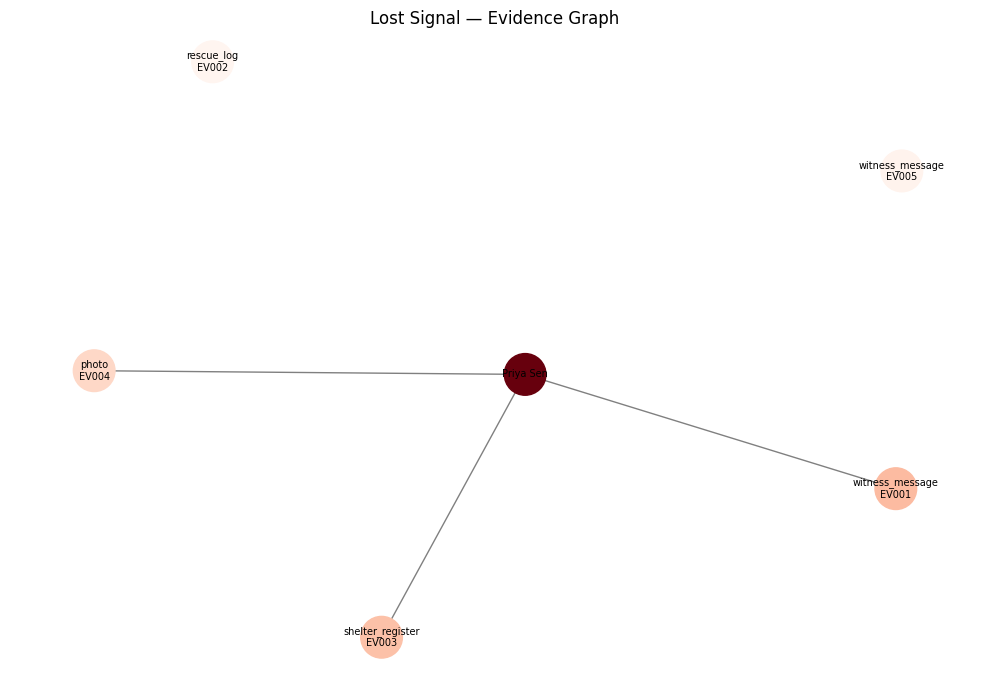

In [32]:
# CELL 15 — Live demo: inject the new clue and recompute
# -----------------------------------------------------------------------------
def run_full_pipeline(evidence_items, target=MISSING_PERSON):
    """
    End-to-end: extract -> score -> contradictions -> graph -> timeline.
    Call this once at the start of the demo with EVIDENCE_ITEMS, then again
    with EVIDENCE_ITEMS + [LIVE_DEMO_CLUE] on stage for the "aha" moment.
    """
    structured = extract_all_evidence(evidence_items)   # uses CELL 10 (fill prompts first)
    scored = score_all_clues(structured, target=target)
    contradictions = detect_contradictions(scored)
    graph = build_evidence_graph(scored, target=target, contradictions=contradictions)
    timeline_fig = build_timeline_figure(scored)
    return {
        "scored_clues": scored,
        "contradictions": contradictions,
        "graph": graph,
        "timeline_fig": timeline_fig,
    }
 
def print_leaderboard(scored_clues, top_n=5):
    print(f"\n=== Top {top_n} leads ===")
    for c in scored_clues[:top_n]:
        print(f"{c['_evidence_id']:8s} | score={c['score']:.3f} | "
              f"loc={c.get('location')!r:20s} | src={c['_source_type']}")
 
# --- BEFORE-DEMO run ---
baseline_result = run_full_pipeline(EVIDENCE_ITEMS)
print_leaderboard(baseline_result["scored_clues"])
draw_evidence_graph(baseline_result["graph"])
baseline_result["timeline_fig"].show()
 
# --- LIVE, ON-STAGE run: add the one new clue and show the ranking shift ---
# live_result = run_full_pipeline(EVIDENCE_ITEMS + [LIVE_DEMO_CLUE])
# print_leaderboard(live_result["scored_clues"])
# draw_evidence_graph(live_result["graph"], highlight_node="EV_LIVE")
# live_result["timeline_fig"].show()

In [33]:
# CELL 16 — Persist evidence store to disk (checkpointing against session loss)
# -----------------------------------------------------------------------------
def save_evidence_store(scored_clues, path=CONFIG["output_json"]):
    with open(path, "w") as f:
        json.dump(scored_clues, f, indent=2, default=str)
    print(f"Saved {len(scored_clues)} scored clues to {path}")
 
def load_evidence_store(path=CONFIG["output_json"]):
    with open(path) as f:
        return json.load(f)
 
save_evidence_store(baseline_result["scored_clues"])

Saved 5 scored clues to /kaggle/working/evidence_store.json


In [ ]:

# CELL 17 (OPTIONAL) — Gradio interface, only build if ahead of schedule
# -----------------------------------------------------------------------------
# import gradio as gr
#
# def gradio_add_clue_and_rerun(new_clue_text):
#     new_clue = {
#         "id": "EV_LIVE_GRADIO",
#         "type": "witness_message",
#         "raw_input": new_clue_text,
#         "timestamp_hint": None,
#         "location_hint": None,
#     }
#     result = run_full_pipeline(EVIDENCE_ITEMS + [new_clue])
#     return result["timeline_fig"], "\n".join(
#         f"{c['_evidence_id']}: {c['score']:.3f}" for c in result["scored_clues"][:5]
#     )
#
# demo = gr.Interface(
#     fn=gradio_add_clue_and_rerun,
#     inputs=gr.Textbox(label="Add a new clue"),
#     outputs=[gr.Plot(label="Updated timeline"), gr.Textbox(label="Top leads")],
#     title="Lost Signal — Live Lead Update",
# )
# demo.launch(share=True)